# Basis function expansion with the bessel functions

$$ \nabla^2 \Phi (R,z) = 4\pi G \rho(R,z) $$

For systems with a given density profile without corresponding analytical $\Phi (R,z)$, we can turn to a basis function expansion. The bessel functions are advantageous when the systems are very flat $q \lt 3$. 

## Density profile reconstruction

$$ \rho (R,z) = \frac{\Sigma}{2h_z} \exp \left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right) $$

We will explore how the reconstruction improves as we increase the order, for different ratios of $h_R$ to $h_z$. Where $q=\frac{h_R}{h_z}$. Note that this $q$ has a slightly different definition as the flattening for the spheroidal coordinate. 

In [37]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 12,
    }
)

In [2]:
def make_nx4_panel(
    nrows,
    page_width=8.25,
    margin_left=0.8,
    margin_right=0.4,
    margin_bottom=0.5,
    margin_top=0.25,
    gap=0.18,
    y_label_space=0.75,
    x_label_space=0.45,
    title_space=2.5,
    xlabel=None,
    ylabel=None,
    title=None,
):
    """Build touching nrows x 4 layout with a centre gap between columns 2 and 3."""
    usable_w = page_width - margin_left - margin_right
    panel = (usable_w - gap - y_label_space) / 4.0
    if panel <= 0:
        raise ValueError("Panel size <= 0. Increase page width or reduce margins/spaces.")

    fig_h = margin_bottom + x_label_space + nrows * panel + title_space + margin_top
    fig = plt.figure(figsize=(page_width, fig_h))
    axes = np.empty((nrows, 4), dtype=object)

    x0 = margin_left + y_label_space
    y0 = margin_bottom + x_label_space
    for r in range(nrows):
        for c in range(4):
            x_in = x0 + c * panel + (gap if c >= 2 else 0.0)
            y_in = y0 + (nrows - 1 - r) * panel
            ax = fig.add_axes(
                [x_in / page_width, y_in / fig_h, panel / page_width, panel / fig_h]
            )
            ax.set_box_aspect(1.0)
            if r < nrows - 1:
                ax.tick_params(labelbottom=False)
            if c > 0:
                ax.tick_params(labelleft=False)
            axes[r, c] = ax

    if xlabel is not None:
        xc = (x0 + 2.0 * panel + 0.5 * gap) / page_width
        fig.supxlabel(xlabel, x=xc, y=(margin_bottom + 0.40 * x_label_space) / fig_h)
    if ylabel is not None:
        fig.supylabel(ylabel, x=(margin_left + 0.45 * y_label_space) / page_width)
    if title is not None:
        yt = (y0 + nrows * panel + 0.50 * title_space) / fig_h
        fig.suptitle(title, y=yt, va="top", ha="center", multialignment="center")

    return fig, axes



In [16]:
# analytical rho 
def exponential_disk(params,x,y,z):
    sigma,hR,hz = params
    R = np.sqrt(x**2 + y**2)
    return (sigma/(2*hz)) * np.exp ( - (R/hR) - np.abs(z)/hz)

In [81]:
# look at slice 
sigma,s,q = 1, 1, 0.3
hz = s*q
hR = s
params = sigma,hR,hz
factor = 10
npoints= 100
x,z=np.linspace(-factor*s,factor*s,npoints),np.linspace(-factor*s,factor*s,npoints)
X,Z = np.meshgrid(x,z,indexing="xy")
rho = np.zeros_like(X)
for i in range(npoints):
    rho[i] = exponential_disk(params,X[i],np.zeros_like(x),Z[i])

vmin = 1e-5
vmax = 1 
Norm = mpl.colors.LogNorm(vmin=vmin,vmax=vmax)
levels = np.logspace(np.log10(vmin),np.log10(vmax),10)
cmap = mpl.colormaps.get_cmap("magma")

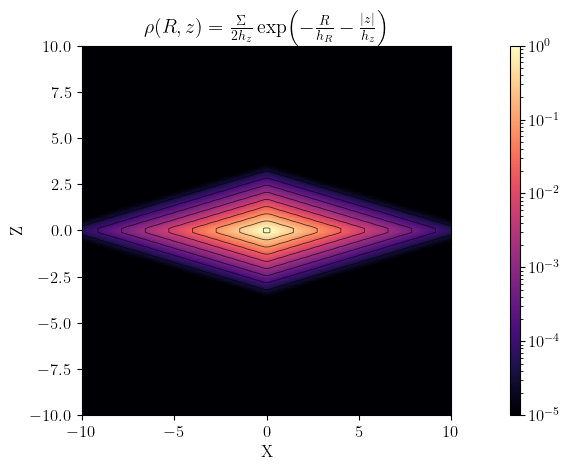

In [82]:
title = r"$\rho(R,z)=  \frac{\Sigma}{2h_z} \exp\!\left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right)$"
fig,axis=plt.subplots(1,2,width_ratios=[50,1],)
okay=axis[0].pcolormesh(X,Z,rho,shading='gouraud',cmap=cmap,norm=Norm)
axis[0].contour(X,Z,rho,levels=levels,colors="k", linewidths=0.6, alpha=0.7)
AXIS={"xlabel":"X","ylabel":"Z","aspect":"equal","title":title}
axis[0].set(**AXIS);
sm = mpl.cm.ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=axis[1])
fig.subplots_adjust(wspace=0,hspace=0)

In [ ]:
# now approximate with the bessel functions...

In [15]:

# $$ \rho (R,z) = \frac{\Sigma}{2h_z} \exp \left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right) $$

title_text = (
    "Verification: Bessel functions \n"
    r"$\rho(R,z)=  \frac{\Sigma}{2h_z} \exp\!\left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right)$"
)

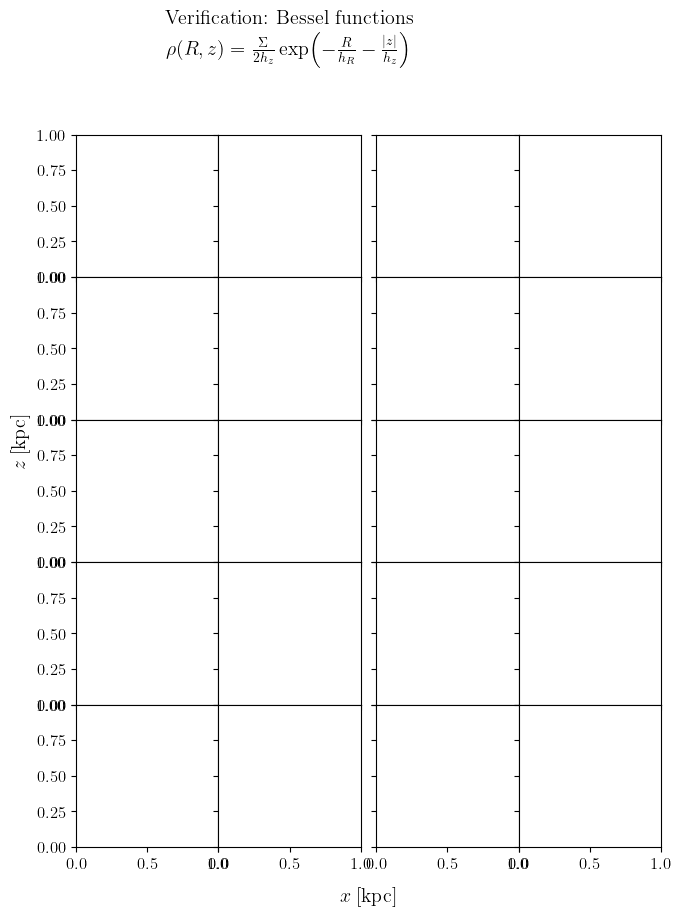

In [14]:
q_values = [0.05, 0.1, 0.2, 0.3, 0.6]

fig, axes = make_nx4_panel(
    nrows=len(q_values),
    gap=0.15,
    y_label_space=1.2,
    x_label_space=1.,
    xlabel=r"$x\;[\mathrm{kpc}]$",
    ylabel=r"$z\;[\mathrm{kpc}]$",
    title=title_text,
    margin_top = 0 
)